# Notebook 6: Gene-Level Aging Prediction and SHAP Interpretation

The previous notebook used PCA and SVD features to test whether single-cell transcriptional information could predict mouse age. These reduced features were useful for prediction, but they could not directly identify individual genes associated with the model’s decisions.

In this notebook, I train a gene-level Random Forest model using selected gene-expression features and apply SHAP to identify which genes contribute most strongly to age prediction. The goal is to interpret the model cautiously and distinguish age-associated signals from possible tissue, cell-type, sex, and mouse-level effects.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
from pathlib import Path
import scanpy as sc

project_folder = Path.home() / "single-cell-aging-clock"

aging_data_path = (
    project_folder
    / "data"
    / "processed"
    / "tabula_muris_senis_dev_subset.h5ad"
)

print("Current folder:", Path.cwd())
print("Project folder:", project_folder)
print("Dataset path:", aging_data_path)
print("File exists:", aging_data_path.exists())

if not aging_data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {aging_data_path}"
    )

aging_data = sc.read_h5ad(aging_data_path)

print("\nDataset loaded successfully.")
print(aging_data)

Current folder: /Users/palaksharma/aging-clock-env
Project folder: /Users/palaksharma/single-cell-aging-clock
Dataset path: /Users/palaksharma/single-cell-aging-clock/data/processed/tabula_muris_senis_dev_subset.h5ad
File exists: True

Dataset loaded successfully.
AnnData object with n_obs × n_vars = 5218 × 22966
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'age_months'
    var: 'n_cells', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'age_colors', 'cell_ontology_class_colors', 'leiden', 'louvain', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [3]:
required_metadata_columns = [
    "age",
    "age_months",
    "mouse.id",
    "sex",
    "tissue",
    "cell_ontology_class"
]

missing_columns = [
    column_name
    for column_name in required_metadata_columns
    if column_name not in aging_data.obs.columns
]

print("Missing metadata columns:", missing_columns)

print("\nAge distribution:")
print(aging_data.obs["age"].value_counts())

print("\nNumber of mice:")
print(aging_data.obs["mouse.id"].nunique())

print("\nExpression matrix shape:")
print(aging_data.X.shape)

Missing metadata columns: []

Age distribution:
age
18m    1960
24m    1877
3m     1381
Name: count, dtype: int64

Number of mice:
14

Expression matrix shape:
(5218, 22966)


## Recreating the mouse-level train/test split

I use the same mouse-based splitting strategy as Notebook 5 so that the gene-level model can be compared with the earlier PCA and SVD models.

Cells from the same mouse are kept together in either the training or testing set. This prevents the model from being trained and evaluated on different cells from the same biological individual.


In [4]:
mouse_age_table = aging_data.obs[
    ["mouse.id", "age", "age_months"]
].drop_duplicates()

random_generator = np.random.default_rng(42)

test_mouse_ids = []

for age_group, mice_from_this_age in mouse_age_table.groupby(
    "age",
    observed=True
):
    available_mice = mice_from_this_age["mouse.id"].unique()

    if len(available_mice) == 1:
        continue

    number_of_test_mice = max(
        1,
        int(round(len(available_mice) * 0.25))
    )

    number_of_test_mice = min(
        number_of_test_mice,
        len(available_mice) - 1
    )

    selected_test_mice = random_generator.choice(
        available_mice,
        size=number_of_test_mice,
        replace=False
    )

    test_mouse_ids.extend(selected_test_mice)

print("Test mice:")
print(test_mouse_ids)

Test mice:
['3_39_F', '3_11_M', '18_47_F', '24_59_M']


In [5]:
test_cell_mask = aging_data.obs["mouse.id"].isin(test_mouse_ids)
train_cell_mask = ~test_cell_mask

train_cell_mask_array = train_cell_mask.to_numpy()
test_cell_mask_array = test_cell_mask.to_numpy()

training_metadata = aging_data.obs.loc[train_cell_mask].copy()
testing_metadata = aging_data.obs.loc[test_cell_mask].copy()

training_mice = set(training_metadata["mouse.id"])
testing_mice = set(testing_metadata["mouse.id"])

overlapping_mice = training_mice.intersection(testing_mice)

print("Training cells:", train_cell_mask_array.sum())
print("Testing cells:", test_cell_mask_array.sum())
print("Training mice:", len(training_mice))
print("Testing mice:", len(testing_mice))
print("Overlapping mice:", overlapping_mice)

assert len(overlapping_mice) == 0

Training cells: 3894
Testing cells: 1324
Training mice: 10
Testing mice: 4
Overlapping mice: set()


## Selecting highly variable genes from training cells only

Single-cell datasets contain thousands of genes, but many genes show little useful variation across cells. I therefore select highly variable genes as the input features for the gene-level model.

To reduce data leakage, highly variable genes are identified using only the training cells. The same selected genes are then extracted from the unseen test cells.

In [6]:
# Create a training-only AnnData object
training_data = aging_data[train_cell_mask_array].copy()

print("Training AnnData shape:", training_data.shape)

Training AnnData shape: (3894, 22966)


In [7]:
# Identify highly variable genes using training cells only
sc.pp.highly_variable_genes(
    training_data,
    n_top_genes=2000,
    flavor="seurat",
    subset=False
)

training_hvg_names = training_data.var_names[
    training_data.var["highly_variable"]
]

print("Number of highly variable genes selected:", len(training_hvg_names))
print("\nFirst 10 selected genes:")
print(training_hvg_names[:10].tolist())

Number of highly variable genes selected: 2271

First 10 selected genes:
['0610037P05Rik', '0610040F04Rik', '1110036E04Rik', '1110038F14Rik', '1110059M19Rik', '1500012K07Rik', '1500016L03Rik', '1600019K03Rik', '1700001J03Rik', '1700001J11Rik']


In [8]:
selected_gene_mask = aging_data.var_names.isin(training_hvg_names)

train_gene_expression = aging_data[
    train_cell_mask_array,
    selected_gene_mask
].X

test_gene_expression = aging_data[
    test_cell_mask_array,
    selected_gene_mask
].X

selected_gene_names = aging_data.var_names[
    selected_gene_mask
].to_numpy()

train_cell_ages = (
    aging_data.obs.loc[train_cell_mask, "age_months"]
    .astype(float)
    .to_numpy()
)

test_cell_ages = (
    aging_data.obs.loc[test_cell_mask, "age_months"]
    .astype(float)
    .to_numpy()
)

print("Training gene-expression shape:", train_gene_expression.shape)
print("Testing gene-expression shape:", test_gene_expression.shape)
print("Training age-label shape:", train_cell_ages.shape)
print("Testing age-label shape:", test_cell_ages.shape)

Training gene-expression shape: (3894, 2271)
Testing gene-expression shape: (1324, 2271)
Training age-label shape: (3894,)
Testing age-label shape: (1324,)


In [9]:
print(
    "HVGs marked in training data:",
    int(training_data.var["highly_variable"].sum())
)

print(
    "Are gene names unique?",
    aging_data.var_names.is_unique
)

print(
    "Number of duplicated gene names:",
    aging_data.var_names.duplicated().sum()
)

HVGs marked in training data: 2271
Are gene names unique? True
Number of duplicated gene names: 0


## Selecting highly variable genes from training cells only

I requested approximately 2,000 highly variable genes using the Seurat dispersion method. Scanpy retained 2,271 genes because several genes were tied at the normalized-dispersion cutoff.

I kept all tied genes rather than removing genes arbitrarily. Importantly, this feature-selection step was performed using training cells only, so the test mice did not influence which genes were selected.

In [10]:
gene_level_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

gene_level_model.fit(
    train_gene_expression,
    train_cell_ages
)

print("Gene-level Random Forest trained.")

Gene-level Random Forest trained.


In [11]:
gene_level_predictions = gene_level_model.predict(
    test_gene_expression
)

gene_level_mae = mean_absolute_error(
    test_cell_ages,
    gene_level_predictions
)

gene_level_r2 = r2_score(
    test_cell_ages,
    gene_level_predictions
)

print("Gene-level Random Forest")
print("Cell-level MAE:", gene_level_mae)
print("Cell-level R²:", gene_level_r2)

Gene-level Random Forest
Cell-level MAE: 7.279280292763767
Cell-level R²: -0.06475944085309004


## Initial gene-level model performance

The gene-level Random Forest produced a cell-level MAE of approximately 7.28 months and a negative R² score. This indicates that the model did not generalize well to cells from unseen mice.

Using individual genes increased interpretability, but it also introduced thousands of sparse and correlated features. Since the training data contains only 10 independent mice, the model may have learned cell-type, tissue, sex, or mouse-specific expression patterns instead of a general aging signal.

Therefore, I do not treat this model as a successful aging clock. Before applying SHAP, I first examine whether its predictions show any meaningful age ordering and whether performance improves when biological heterogeneity is reduced.

In [12]:
gene_level_results = testing_metadata[
    [
        "mouse.id",
        "age",
        "age_months",
        "tissue",
        "cell_ontology_class"
    ]
].copy()

gene_level_results["predicted_age_months"] = (
    gene_level_predictions
)

gene_level_results.groupby(
    "age_months",
    observed=True
)["predicted_age_months"].describe()

,count,mean,std,min,25%,50%,75%,max
age_months,,,,,,,,
3,458.0,16.199969,3.555501,3.460731,14.011228,17.072387,18.693776,21.320841
18,428.0,15.394881,5.098942,3.093112,13.007482,17.703675,18.849786,21.317647
24,438.0,19.451788,2.787562,3.322229,19.005643,20.506451,20.992389,21.419442


## Prediction pattern across age groups

The gene-level model did not produce a clear monotonic age pattern. Mean predicted age was approximately 16.20 months for 3-month cells, 15.39 months for 18-month cells, and 19.45 months for 24-month cells.

Although the model assigned somewhat higher predictions to the oldest group, it did not distinguish 3-month and 18-month cells correctly. The prediction distributions also showed substantial overlap, particularly between the younger and middle-aged groups.

This supports the negative R² result and suggests that the model is learning a mixture of age, cell-type, tissue, sex, and mouse-specific expression patterns rather than a reliable general aging signal.

In [13]:
gene_mouse_summary = (
    gene_level_results
    .groupby("mouse.id", observed=True)
    .agg(
        actual_age_months=("age_months", "first"),
        predicted_age_months=("predicted_age_months", "mean"),
        number_of_cells=("predicted_age_months", "size")
    )
    .reset_index()
)

gene_mouse_summary["absolute_error_months"] = (
    gene_mouse_summary["actual_age_months"].astype(float)
    - gene_mouse_summary["predicted_age_months"].astype(float)
).abs()

gene_mouse_summary

,mouse.id,actual_age_months,predicted_age_months,number_of_cells,absolute_error_months
0,3_11_M,3,15.411082,122,12.411082
1,3_39_F,3,16.486410,336,13.486410
2,18_47_F,18,15.394881,428,2.605119
3,24_59_M,24,19.451788,438,4.548212


In [14]:
gene_mouse_mae = gene_mouse_summary[
    "absolute_error_months"
].mean()

print("Gene-level mouse MAE:", gene_mouse_mae)

Gene-level mouse MAE: 8.262705999611285


## Mouse-level evaluation

The gene-level model produced a mouse-level MAE of approximately 8.26 months. Averaging cell predictions within each mouse did not improve performance compared with the cell-level MAE of approximately 7.28 months.

This suggests that the model is not learning a stable age-associated signal across biological individuals. Instead, predictions may be strongly influenced by cell type, tissue, sex, or mouse-specific transcriptional patterns.

The mixed-cell gene-level model is therefore retained as a negative baseline rather than treated as a reliable aging clock.

In [15]:
cell_type_cell_counts = (
    aging_data.obs
    .groupby(
        ["cell_ontology_class", "age"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
)

cell_type_mouse_counts = (
    aging_data.obs
    .groupby(
        ["cell_ontology_class", "age"],
        observed=True
    )["mouse.id"]
    .nunique()
    .unstack(fill_value=0)
)

cell_type_summary = pd.concat(
    {
        "cell_count": cell_type_cell_counts,
        "mouse_count": cell_type_mouse_counts
    },
    axis=1
)

cell_type_summary["total_cells"] = (
    cell_type_cell_counts.sum(axis=1)
)

cell_type_summary.sort_values(
    "total_cells",
    ascending=False
).head(20)

cell_count            \
age                                                     3m  18m  24m   
cell_ontology_class                                                    
bronchial smooth muscle cell                           420  944  753   
fibroblast of lung                                     129  169  185   
myeloid dendritic cell                                  52  108  213   
adventitial cell                                       140   98   51   
B cell                                                  55   77  144   
classical monocyte                                      68   80   54   
type II pneumocyte                                      96   38   33   
vein endothelial cell                                   39   60   53   
non-classical monocyte                                  56   36   57   
neutrophil                                              29   59   35   
CD8-positive, alpha-beta T cell                          9   48   62   
smooth muscle cell of the pulmonary artery              55   47    9   
endothelial cell of lymphatic vessel                    51   13   35   
dendritic cell                                          10    9   43   
CD4-positive, alpha-beta T cell                         36   22    1   
NK cell                                                 27   18    7   
ciliated columnar cell of tracheobronchial tree         21   14   17   
pulmonary interstitial fibroblast                       39    4    7   
regulatory T cell                                        1   20   26   
leukocyte                                                2    5   31   

                                                mouse_count          \
age                                                      3m 18m 24m   
cell_ontology_class                                                   
bronchial smooth muscle cell                              6   4   4   
fibroblast of lung                                        6   4   4   
myeloid dendritic cell                                    4   4   4   
adventitial cell                                          6   4   4   
B cell                                                    6   4   4   
classical monocyte                                        6   4   4   
type II pneumocyte                                        6   4   4   
vein endothelial cell                                     5   4   4   
non-classical monocyte                                    6   4   4   
neutrophil                                                6   4   4   
CD8-positive, alpha-beta T cell                           4   4   4   
smooth muscle cell of the pulmonary artery                5   4   3   
endothelial cell of lymphatic vessel                      5   3   4   
dendritic cell                                            2   3   4   
CD4-positive, alpha-beta T cell                           5   4   1   
NK cell                                                   5   4   2   
ciliated columnar cell of tracheobronchial tree           6   3   3   
pulmonary interstitial fibroblast                         6   4   2   
regulatory T cell                                         1   4   4   
leukocyte                                                 2   3   2   

                                                total_cells  
age                                                          
cell_ontology_class                                          
bronchial smooth muscle cell                           2117  
fibroblast of lung                                      483  
myeloid dendritic cell                                  373  
adventitial cell                                        289  
B cell                                                  276  
classical monocyte                                      202  
type II pneumocyte                                      167  
vein endothelial cell                                   152  
non-classical monocyte                                  149  
neutrophil   

In [16]:
candidate_cell_types = cell_type_summary[
    (cell_type_cell_counts > 50).all(axis=1)
    & (cell_type_mouse_counts >= 2).all(axis=1)
].sort_values(
    "total_cells",
    ascending=False
)

candidate_cell_types

cell_count           mouse_count          \
age                                  3m  18m  24m          3m 18m 24m   
cell_ontology_class                                                     
bronchial smooth muscle cell        420  944  753           6   4   4   
fibroblast of lung                  129  169  185           6   4   4   
myeloid dendritic cell               52  108  213           4   4   4   
adventitial cell                    140   98   51           6   4   4   
B cell                               55   77  144           6   4   4   
classical monocyte                   68   80   54           6   4   4   

                             total_cells  
age                                       
cell_ontology_class                       
bronchial smooth muscle cell        2117  
fibroblast of lung                   483  
myeloid dendritic cell               373  
adventitial cell                     289  
B cell                               276  
classical monocyte                   202

## Cell-type-specific aging model

The mixed-cell gene-level model performed poorly, likely because the model was exposed to many different cell types at once. In that setting, cell-type and tissue signals may dominate over age-related transcriptional signals.

To reduce this source of variation, I next focus on one well-represented cell type: bronchial smooth muscle cells. This cell type is present across all three age groups and multiple mice, making it a reasonable candidate for a cell-type-specific aging model.

In [17]:
selected_cell_type = "bronchial smooth muscle cell"

cell_type_mask = (
    aging_data.obs["cell_ontology_class"] == selected_cell_type
)

cell_type_data = aging_data[cell_type_mask].copy()

print(cell_type_data)
print("\nAge distribution:")
print(cell_type_data.obs["age"].value_counts())

print("\nMice per age group:")
print(
    cell_type_data.obs
    .groupby("age", observed=True)["mouse.id"]
    .nunique()
)

AnnData object with n_obs × n_vars = 2117 × 22966
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'age_months'
    var: 'n_cells', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'age_colors', 'cell_ontology_class_colors', 'leiden', 'louvain', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

Age distribution:
age
18m    944
24m    753
3m     420
Name: count, dtype: int64

Mice per age group:
age
3m     6
18m    4
24m    4
Name: mouse.id, dtype: int64


In [18]:
cell_type_test_mask = cell_type_data.obs["mouse.id"].isin(test_mouse_ids)
cell_type_train_mask = ~cell_type_test_mask

cell_type_train_mask_array = cell_type_train_mask.to_numpy()
cell_type_test_mask_array = cell_type_test_mask.to_numpy()

cell_type_training_metadata = cell_type_data.obs.loc[
    cell_type_train_mask
].copy()

cell_type_testing_metadata = cell_type_data.obs.loc[
    cell_type_test_mask
].copy()

print("Training cells:", cell_type_train_mask_array.sum())
print("Testing cells:", cell_type_test_mask_array.sum())

print("\nTraining age distribution:")
print(cell_type_training_metadata["age"].value_counts())

print("\nTesting age distribution:")
print(cell_type_testing_metadata["age"].value_counts())

print("\nTraining mice:", cell_type_training_metadata["mouse.id"].nunique())
print("Testing mice:", cell_type_testing_metadata["mouse.id"].nunique())

overlapping_cell_type_mice = set(
    cell_type_training_metadata["mouse.id"]
).intersection(
    set(cell_type_testing_metadata["mouse.id"])
)

print("Overlapping mice:", overlapping_cell_type_mice)

assert len(overlapping_cell_type_mice) == 0

Training cells: 1582
Testing cells: 535

Training age distribution:
age
18m    724
24m    575
3m     283
Name: count, dtype: int64

Testing age distribution:
age
18m    220
24m    178
3m     137
Name: count, dtype: int64

Training mice: 10
Testing mice: 4
Overlapping mice: set()


In [19]:
cell_type_training_data = cell_type_data[
    cell_type_train_mask_array
].copy()

sc.pp.highly_variable_genes(
    cell_type_training_data,
    n_top_genes=1000,
    flavor="seurat",
    subset=False
)

cell_type_hvg_mask = (
    cell_type_training_data.var["highly_variable"]
    .to_numpy()
)

print("Number of selected genes:", cell_type_hvg_mask.sum())

Number of selected genes: 1000


In [20]:
cell_type_train_expression = cell_type_data[
    cell_type_train_mask_array,
    cell_type_hvg_mask
].X

cell_type_test_expression = cell_type_data[
    cell_type_test_mask_array,
    cell_type_hvg_mask
].X

cell_type_selected_genes = cell_type_data.var_names[
    cell_type_hvg_mask
].to_numpy()

cell_type_train_ages = (
    cell_type_data.obs.loc[cell_type_train_mask, "age_months"]
    .astype(float)
    .to_numpy()
)

cell_type_test_ages = (
    cell_type_data.obs.loc[cell_type_test_mask, "age_months"]
    .astype(float)
    .to_numpy()
)

print("Training expression shape:", cell_type_train_expression.shape)
print("Testing expression shape:", cell_type_test_expression.shape)
print("Training age shape:", cell_type_train_ages.shape)
print("Testing age shape:", cell_type_test_ages.shape)

Training expression shape: (1582, 1000)
Testing expression shape: (535, 1000)
Training age shape: (1582,)
Testing age shape: (535,)


In [21]:
cell_type_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

cell_type_model.fit(
    cell_type_train_expression,
    cell_type_train_ages
)

cell_type_predictions = cell_type_model.predict(
    cell_type_test_expression
)

cell_type_mae = mean_absolute_error(
    cell_type_test_ages,
    cell_type_predictions
)

cell_type_r2 = r2_score(
    cell_type_test_ages,
    cell_type_predictions
)

print("Bronchial smooth muscle cell model")
print("Cell-level MAE:", cell_type_mae)
print("Cell-level R²:", cell_type_r2)

Bronchial smooth muscle cell model
Cell-level MAE: 4.488396155985936
Cell-level R²: 0.32649301360959093


## Cell-type-specific model performance

The bronchial smooth muscle cell model performed better than the mixed-cell gene-level model. The cell-level MAE decreased to approximately 4.49 months, and the R² score increased to approximately 0.33.

This suggests that restricting the analysis to one well-represented cell type reduced some of the biological heterogeneity present in the mixed-cell model. Within bronchial smooth muscle cells, the model was better able to detect age-associated transcriptional patterns.

However, the result should still be interpreted cautiously because the test set contains only a small number of mice. The model shows a useful age-related signal, but it is not a fully validated aging clock.


In [22]:
cell_type_prediction_results = cell_type_testing_metadata[
    ["mouse.id", "age", "age_months"]
].copy()

cell_type_prediction_results["predicted_age_months"] = (
    cell_type_predictions
)

cell_type_prediction_results.groupby(
    "age_months",
    observed=True
)["predicted_age_months"].describe()

,count,mean,std,min,25%,50%,75%,max
age_months,,,,,,,,
3,137.0,14.068156,5.104473,3.052500,10.928225,15.946471,17.663717,20.890421
18,220.0,17.755334,1.850382,8.503049,17.234116,18.125598,18.580447,21.822239
24,178.0,20.507177,1.824371,13.458282,19.314389,21.637192,21.776752,21.846024


In [23]:
cell_type_mouse_summary = (
    cell_type_prediction_results
    .groupby("mouse.id", observed=True)
    .agg(
        actual_age_months=("age_months", "first"),
        predicted_age_months=("predicted_age_months", "mean"),
        number_of_cells=("predicted_age_months", "size")
    )
    .reset_index()
)

cell_type_mouse_summary["absolute_error_months"] = (
    cell_type_mouse_summary["actual_age_months"].astype(float)
    - cell_type_mouse_summary["predicted_age_months"].astype(float)
).abs()

cell_type_mouse_summary

,mouse.id,actual_age_months,predicted_age_months,number_of_cells,absolute_error_months
0,3_11_M,3,11.350095,44,8.350095
1,3_39_F,3,15.354120,93,12.354120
2,18_47_F,18,17.755334,220,0.244666
3,24_59_M,24,20.507177,178,3.492823


In [24]:
cell_type_mouse_mae = cell_type_mouse_summary[
    "absolute_error_months"
].mean()

print("Bronchial smooth muscle cell mouse-level MAE:", cell_type_mouse_mae)

Bronchial smooth muscle cell mouse-level MAE: 6.110426038098333


In [25]:
model_comparison = pd.DataFrame({
    "model": [
        "Mixed-cell gene model",
        "Bronchial smooth muscle cell gene model"
    ],
    "cell_level_mae": [
        gene_level_mae,
        cell_type_mae
    ],
    "cell_level_r2": [
        gene_level_r2,
        cell_type_r2
    ]
})

model_comparison.round(3)

,model,cell_level_mae,cell_level_r2
0,Mixed-cell gene model,7.279,-0.065
1,Bronchial smooth muscle cell gene model,4.488,0.326


The cell-type-specific model performed better than the mixed-cell gene-level model. The mixed-cell model had a negative R² score, while the bronchial smooth muscle cell model reached an R² of approximately 0.33 and reduced the MAE from about 7.28 months to about 4.49 months.

This suggests that restricting the analysis to one cell type helped reduce biological heterogeneity. Instead of learning broad differences between cell types, the model could focus more on age-associated gene-expression variation within bronchial smooth muscle cells.

Because this cell-type-specific model shows a clearer predictive signal, I use it for SHAP-based gene interpretation.

In [26]:
import shap
from scipy import sparse

In [27]:
number_of_shap_cells = min(
    300,
    cell_type_test_expression.shape[0]
)

random_generator = np.random.default_rng(42)

shap_cell_indices = random_generator.choice(
    cell_type_test_expression.shape[0],
    size=number_of_shap_cells,
    replace=False
)

shap_test_expression = cell_type_test_expression[
    shap_cell_indices
]

if sparse.issparse(shap_test_expression):
    shap_test_expression = shap_test_expression.toarray()

shap_test_expression = pd.DataFrame(
    shap_test_expression,
    columns=cell_type_selected_genes
)

print("SHAP test expression shape:", shap_test_expression.shape)

SHAP test expression shape: (300, 1000)


In [28]:
explainer = shap.TreeExplainer(
    cell_type_model
)

shap_values = explainer.shap_values(
    shap_test_expression
)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (300, 1000)


In [29]:
mean_absolute_shap_values = np.abs(
    shap_values
).mean(axis=0)

top_shap_genes = pd.DataFrame({
    "gene": cell_type_selected_genes,
    "mean_absolute_shap_value": mean_absolute_shap_values
}).sort_values(
    "mean_absolute_shap_value",
    ascending=False
)

top_shap_genes.head(20)

,gene,mean_absolute_shap_value
507,Iapp,1.266750
260,Csnk2a1,0.956108
185,C1qb,0.606315
557,Krt15,0.391624
671,Nptn,0.251749
953,Tubb4a,0.240825
264,Cx3cr1,0.204087
796,Rps26,0.192753
794,Rpl34-ps1,0.190526
799,S100a9,0.149852


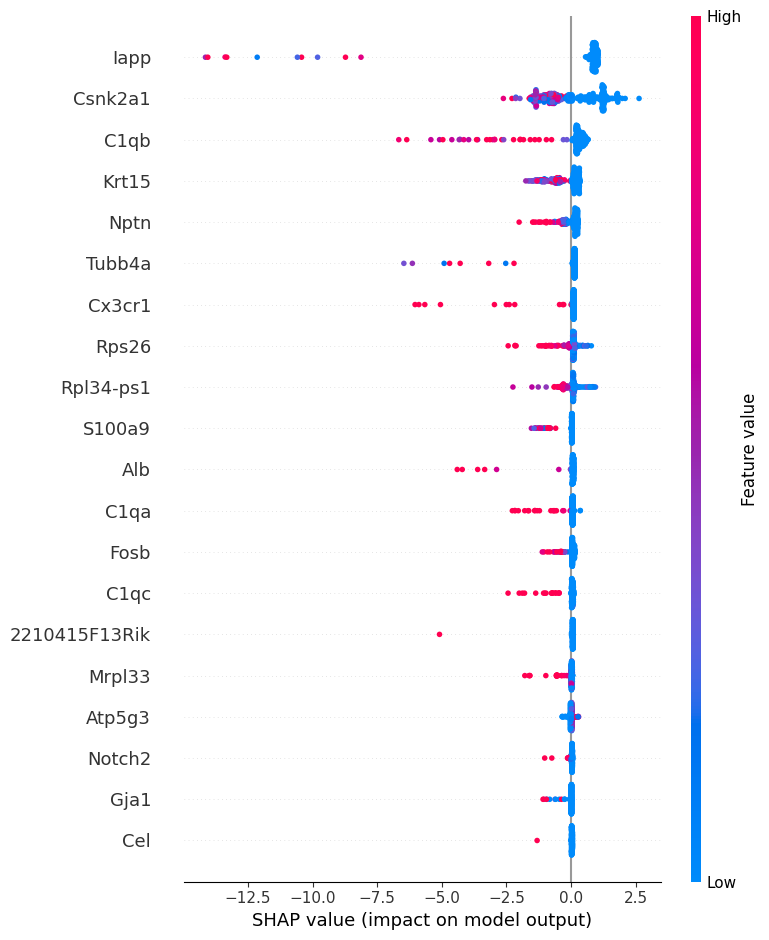

In [30]:
shap.summary_plot(
    shap_values,
    shap_test_expression,
    max_display=20
)

## SHAP interpretation

I apply SHAP to the bronchial smooth muscle cell model because this model showed better predictive performance than the mixed-cell gene model.

SHAP values explain how each gene contributes to the model’s age predictions. A high SHAP value does not prove that a gene causes aging. It only means that the gene was important for this model’s predictions.

In [31]:
top_gene_names = top_shap_genes["gene"].head(20).tolist()

top_gene_expression = pd.DataFrame(
    cell_type_data[:, top_gene_names].X.toarray()
    if sparse.issparse(cell_type_data[:, top_gene_names].X)
    else cell_type_data[:, top_gene_names].X,
    columns=top_gene_names
)

top_gene_expression["age"] = cell_type_data.obs["age"].values

mean_expression_by_age = (
    top_gene_expression
    .groupby("age")
    .mean()
    .T
)

mean_expression_by_age

/var/folders/ys/f4dnpd295d91m1ctpdbcgl3w0000gn/T/ipykernel_88663/3414304297.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("age")


age,3m,18m,24m
Iapp,0.234369,0.000026,0.001776
Csnk2a1,0.724451,1.121464,0.295242
C1qb,0.121087,0.036001,0.019308
Krt15,0.027693,0.030406,0.022959
Nptn,0.522837,0.571651,0.104677
Tubb4a,0.050993,0.021650,0.026398
Cx3cr1,0.061847,0.000817,0.000000
Rps26,0.863468,0.428935,0.621840
Rpl34-ps1,0.881149,0.436887,0.751730
S100a9,0.007086,0.009141,0.026754


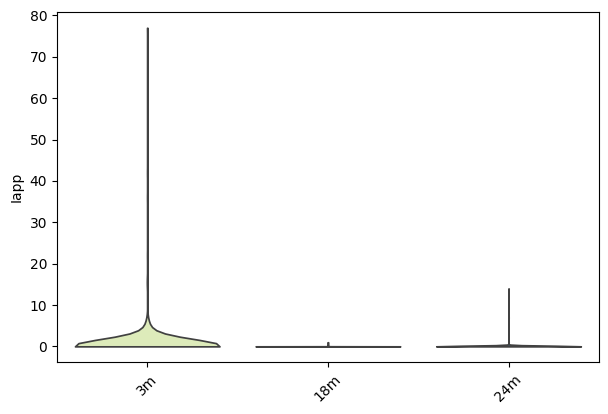

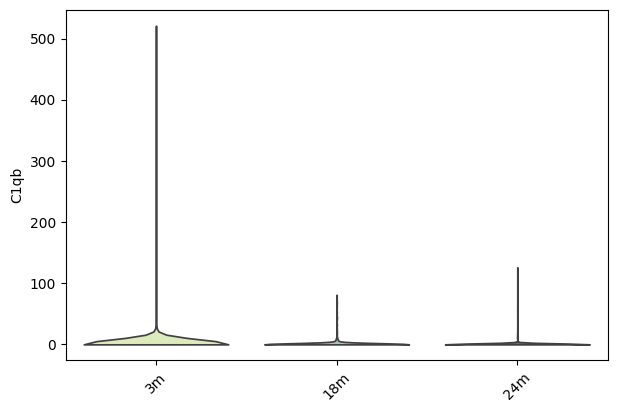

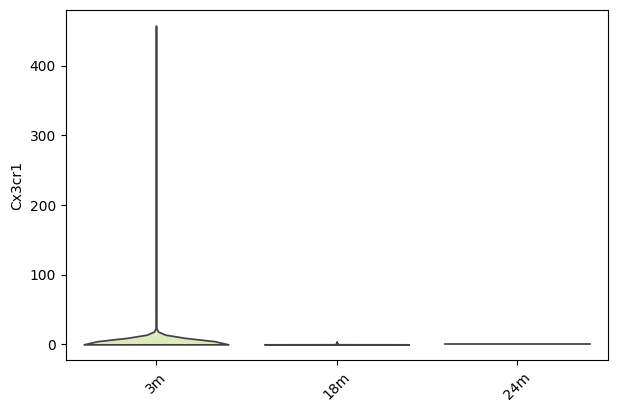

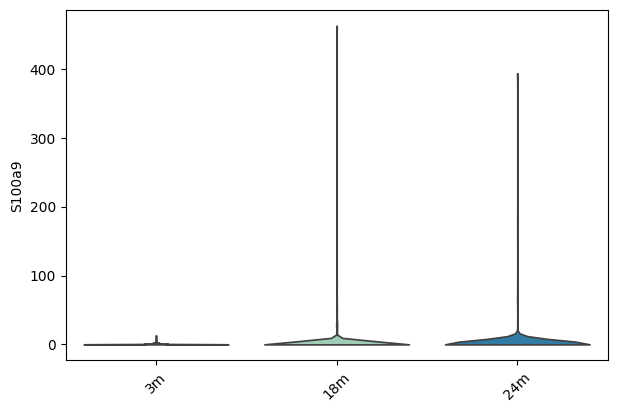

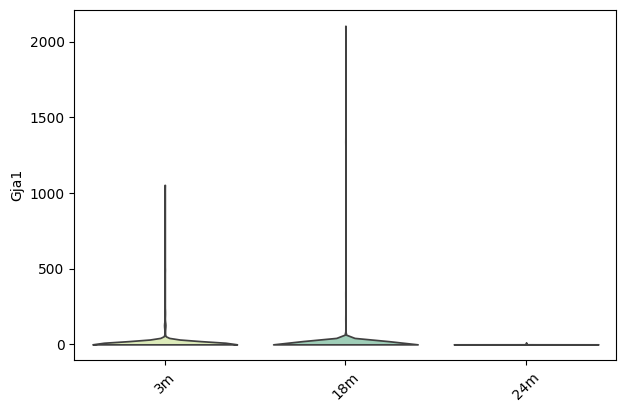

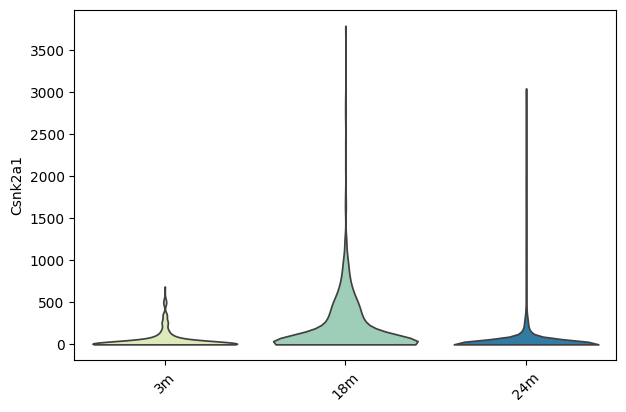

In [32]:
genes_to_plot = [
    "Iapp",
    "C1qb",
    "Cx3cr1",
    "S100a9",
    "Gja1",
    "Csnk2a1"
]

for gene_name in genes_to_plot:
    sc.pl.violin(
        cell_type_data,
        keys=gene_name,
        groupby="age",
        stripplot=False,
        rotation=45
    )

Because SHAP explains the trained model rather than the underlying biology directly, these genes should be treated as candidates for follow-up rather than validated aging markers.

In [33]:
top_gene_names = top_shap_genes["gene"].head(20).tolist()

top_gene_expression_matrix = cell_type_data[:, top_gene_names].X

if sparse.issparse(top_gene_expression_matrix):
    top_gene_expression_matrix = top_gene_expression_matrix.toarray()

top_gene_expression = pd.DataFrame(
    top_gene_expression_matrix,
    columns=top_gene_names
)

top_gene_expression["age"] = cell_type_data.obs["age"].values

mean_expression_by_age = (
    top_gene_expression
    .groupby("age")
    .mean()
    .T
)

mean_expression_by_age

/var/folders/ys/f4dnpd295d91m1ctpdbcgl3w0000gn/T/ipykernel_88663/4109711763.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("age")


age,3m,18m,24m
Iapp,0.234369,0.000026,0.001776
Csnk2a1,0.724451,1.121464,0.295242
C1qb,0.121087,0.036001,0.019308
Krt15,0.027693,0.030406,0.022959
Nptn,0.522837,0.571651,0.104677
Tubb4a,0.050993,0.021650,0.026398
Cx3cr1,0.061847,0.000817,0.000000
Rps26,0.863468,0.428935,0.621840
Rpl34-ps1,0.881149,0.436887,0.751730
S100a9,0.007086,0.009141,0.026754


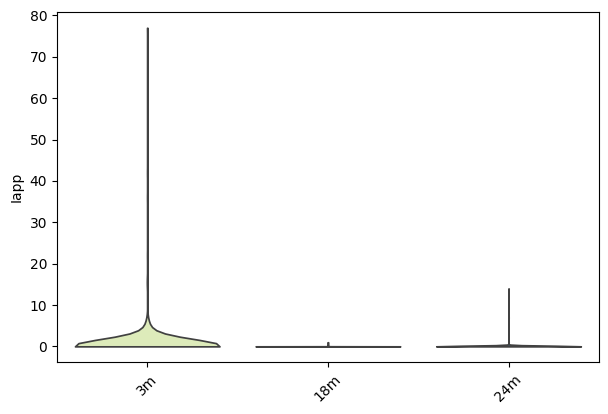

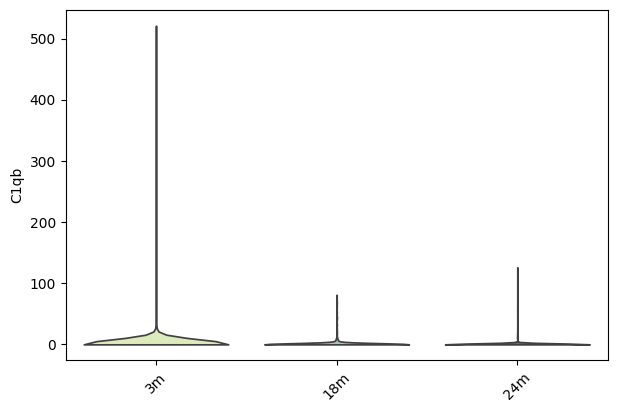

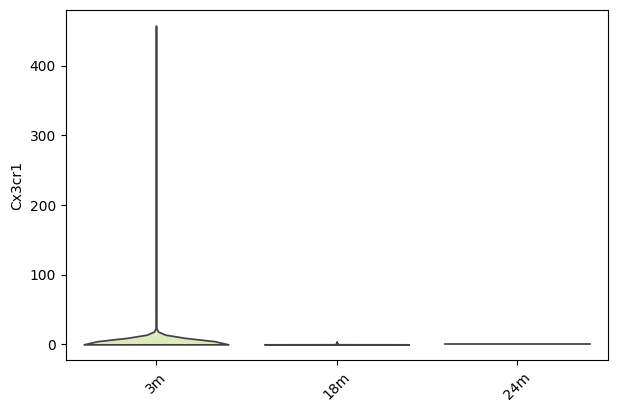

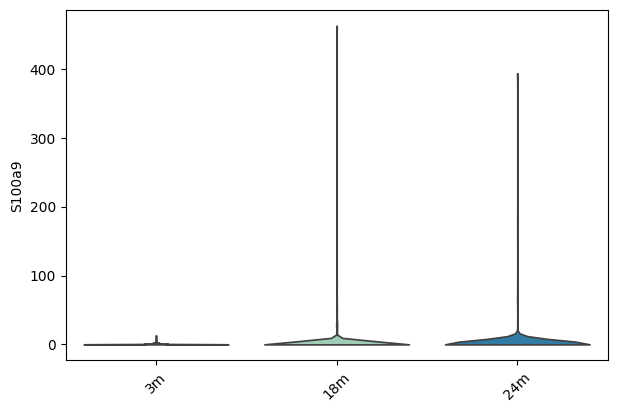

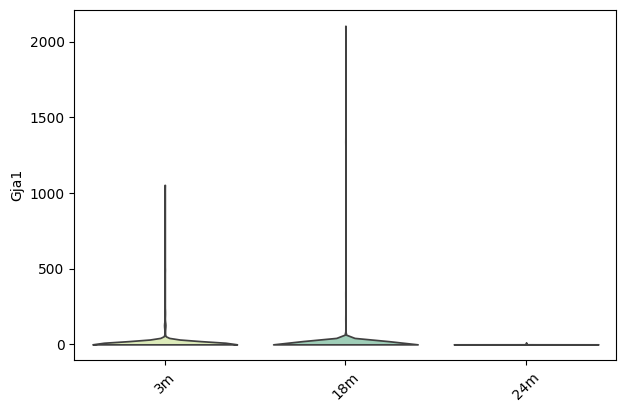

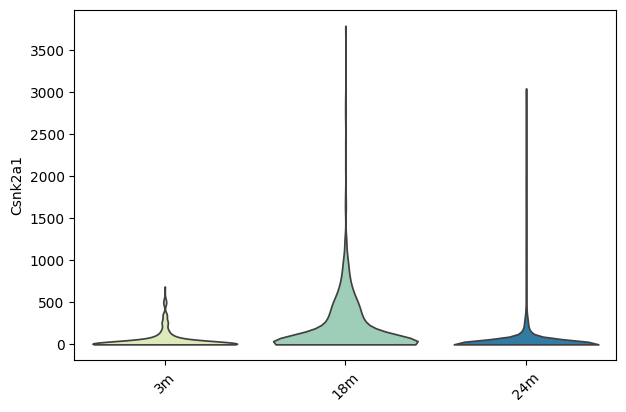

In [34]:
genes_to_plot = [
    "Iapp",
    "C1qb",
    "Cx3cr1",
    "S100a9",
    "Gja1",
    "Csnk2a1"
]

for gene_name in genes_to_plot:
    sc.pl.violin(
        cell_type_data,
        keys=gene_name,
        groupby="age",
        stripplot=False,
        rotation=45
    )

## Final interpretation

The mixed-cell gene-level model performed poorly, suggesting that using all cell types together introduced too much biological heterogeneity. After restricting the analysis to bronchial smooth muscle cells, model performance improved, with a lower MAE and a positive R² score.

SHAP analysis on the bronchial smooth muscle cell model identified genes that contributed most strongly to the model’s age predictions. Some genes, including complement-related genes such as C1qa, C1qb, and C1qc, and inflammatory/immune-associated genes such as Cx3cr1 and S100a9, may reflect age-associated immune or inflammatory signals.

However, several high-ranking genes, including Iapp, Alb, and Cel, are not typical bronchial smooth muscle markers. These may reflect ambient RNA, annotation noise, doublets, or background tissue signal. Therefore, the SHAP genes should be interpreted as model-associated features rather than validated aging biomarkers.

Overall, the cell-type-specific model suggests that age-related transcriptional signal is easier to detect after reducing cell-type heterogeneity, but the results remain preliminary because the dataset contains few mice and only three age groups.

## Limitations

This notebook has several important limitations:

- The test set contains only four mice, so model performance is not a stable estimate of generalization.
- The dataset contains only three age groups: 3 months, 18 months, and 24 months.
- Even within one annotated cell type, there may still be annotation noise, doublets, or ambient RNA.
- SHAP explains the trained model, not biological causality.
- The top SHAP genes should be treated as candidates for follow-up, not confirmed aging biomarkers.
- A stronger future analysis would use more mice, more age groups, external validation, and pathway-level interpretation.